# Principal Component Analysis (PCA)

PCA is a **dimensionality reduction** technique that transforms a dataset with possibly correlated features into a new coordinate system where the axes (principal components) are ordered by the amount of variance they explain.

It is one of the most widely used algorithms in machine learning, statistics, and data science.

---

## Table of Contents
1. [The Problem PCA Solves](#1-the-problem-pca-solves)
2. [Mathematical Foundations](#2-mathematical-foundations)
   - Variance and Covariance
   - The Covariance Matrix
3. [Geometric Intuition](#3-geometric-intuition)
4. [Eigen Decomposition](#4-eigen-decomposition)
   - Eigenvalues and Eigenvectors (from scratch)
   - Connection to PCA
5. [Singular Value Decomposition (SVD)](#5-singular-value-decomposition)
6. [Step-by-Step PCA Algorithm](#6-step-by-step-pca-algorithm)
7. [Explained Variance and Choosing k](#7-explained-variance-and-choosing-k)
8. [Reconstruction and Information Loss](#8-reconstruction-and-information-loss)
9. [PCA vs Feature Selection](#9-pca-vs-feature-selection)
10. [Limitations of PCA](#10-limitations-of-pca)
11. [Implementation from Scratch](#11-implementation-from-scratch)
12. [sklearn PCA on Real Data](#12-sklearn-pca-on-real-data)
13. [PCA for Visualization](#13-pca-for-visualization)
14. [Kernel PCA (Non-linear Extension)](#14-kernel-pca)
15. [Summary and Key Takeaways](#15-summary)

---
## 1. The Problem PCA Solves

### The Curse of Dimensionality

As the number of features grows:
- Data becomes **sparse** — points are far apart in high-dimensional space
- Models **overfit** more easily
- Computation becomes expensive
- Visualization is impossible beyond 3D

### Redundancy in Features

Real-world features are often **correlated**. For example:
- Height and weight in a medical dataset
- Pixel intensities in neighboring image regions
- Word frequencies in related topics

If two features are perfectly correlated, one of them carries **zero new information**. PCA identifies and removes this redundancy.

### What PCA Does

> PCA finds a new set of orthogonal axes (principal components) such that:
> - The **first axis** points in the direction of **maximum variance** in the data
> - The **second axis** is orthogonal to the first and captures the **next most variance**
> - And so on...

By keeping only the top $k$ components, we retain the most important structure in the data while reducing dimensionality from $d$ to $k$.

---
## 2. Mathematical Foundations

### 2.1 Variance

Variance measures how spread out a single variable $x$ is:

$$\text{Var}(x) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

High variance → data is spread out → more information content.

### 2.2 Covariance

Covariance measures how two variables change **together**:

$$\text{Cov}(x, y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

- $\text{Cov}(x,y) > 0$: $x$ and $y$ increase together (positive correlation)
- $\text{Cov}(x,y) < 0$: one increases as the other decreases (negative correlation)
- $\text{Cov}(x,y) = 0$: no linear relationship

Note: $\text{Cov}(x, x) = \text{Var}(x)$

### 2.3 The Covariance Matrix

For a dataset $X$ with $n$ samples and $d$ features, the **covariance matrix** $\Sigma$ is a $d \times d$ symmetric matrix:

$$\Sigma_{ij} = \text{Cov}(x_i, x_j)$$

$$\Sigma = \begin{bmatrix}
\text{Var}(x_1) & \text{Cov}(x_1,x_2) & \cdots & \text{Cov}(x_1,x_d) \\
\text{Cov}(x_2,x_1) & \text{Var}(x_2) & \cdots & \text{Cov}(x_2,x_d) \\
\vdots & \vdots & \ddots & \vdots \\
\text{Cov}(x_d,x_1) & \text{Cov}(x_d,x_2) & \cdots & \text{Var}(x_d)
\end{bmatrix}$$

In matrix form (with centered data $\tilde{X} = X - \bar{X}$):

$$\Sigma = \frac{1}{n-1} \tilde{X}^T \tilde{X}$$

**Key insight**: The covariance matrix completely encodes the linear relationships between all pairs of features. PCA diagonalizes this matrix — finding a rotation that makes all off-diagonal covariances zero.

---
## 3. Geometric Intuition

### Think of a Cloud of Points

Imagine a 2D scatter plot where the data forms an elongated ellipse, tilted at 45 degrees. The data has:
- High spread along the 45° diagonal direction
- Low spread perpendicular to it

**PCA finds this diagonal direction** — that is the first principal component (PC1). PC2 is perpendicular to PC1.

### Projection

When we reduce from 2D to 1D, we **project** all data points onto PC1. The projected value (scalar) is the coordinate of that point in the new 1D space. This projection loses the information along PC2 (the low-variance direction), keeping the most important spread.

### Why Maximum Variance?

After projection, we want to **distinguish** points as much as possible. If we project onto a direction where all points collapse together (low variance), we lose all discriminative information. Maximum variance ↔ maximum information retained.

### Orthogonality of Components

Each successive component must be **orthogonal** (perpendicular) to all previous ones. This ensures:
1. No redundancy between components
2. The components form a valid new coordinate system (orthonormal basis)
3. The total variance is partitioned — each component captures a non-overlapping piece

### The Ellipsoid View

In $d$ dimensions, the data distribution (assuming Gaussian) traces an **ellipsoid**. The principal components are exactly the **axes of this ellipsoid**:
- The longest axis = PC1 (most variance)
- The second longest = PC2
- ...
- The shortest = PC_d (least variance)

The lengths of the axes are proportional to $\sqrt{\lambda_i}$ where $\lambda_i$ are the eigenvalues.

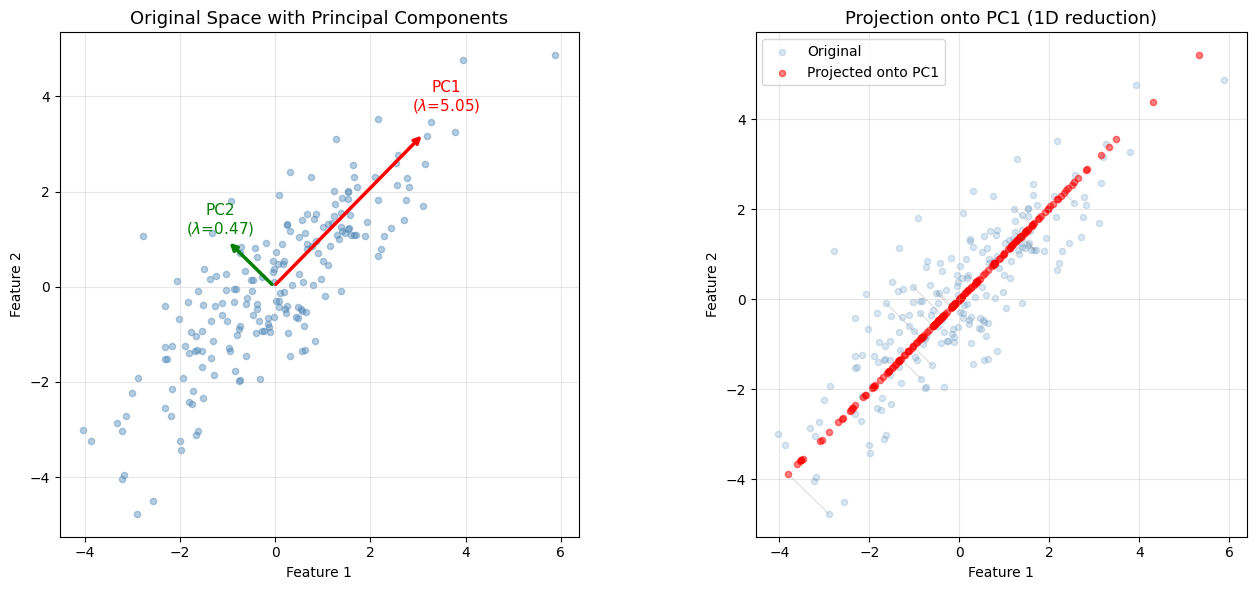

PC1 direction: [0.70039896 0.71375157]
PC1 angle from x-axis: 45.5°
Variance explained by PC1: 91.6%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

np.random.seed(42)

# Generate correlated 2D data
mean = [0, 0]
cov = [[3, 2.5], [2.5, 3]]  # correlated
X = np.random.multivariate_normal(mean, cov, 200)

# Compute covariance and eigen decomposition
cov_matrix = np.cov(X.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: original data with principal components
ax = axes[0]
ax.scatter(X[:, 0], X[:, 1], alpha=0.4, s=20, color='steelblue')
origin = np.mean(X, axis=0)
for i, (val, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    scale = np.sqrt(val) * 2
    ax.annotate('', xy=origin + scale * vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=['red', 'green'][i], lw=2.5))
    ax.text(*(origin + scale * vec * 1.15), f'PC{i+1}\n($\\lambda$={val:.2f})',
            fontsize=11, color=['red', 'green'][i], ha='center')
ax.set_title('Original Space with Principal Components', fontsize=13)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Right: projected onto PC1
ax2 = axes[1]
pc1 = eigenvectors[:, 0]
projections = X @ pc1
X_proj = np.outer(projections, pc1)
ax2.scatter(X[:, 0], X[:, 1], alpha=0.2, s=20, color='steelblue', label='Original')
ax2.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5, s=20, color='red', label='Projected onto PC1')
for i in range(0, len(X), 10):
    ax2.plot([X[i,0], X_proj[i,0]], [X[i,1], X_proj[i,1]], 'gray', alpha=0.3, lw=0.7)
ax2.set_title('Projection onto PC1 (1D reduction)', fontsize=13)
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.set_aspect('equal')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_geometric_intuition.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"PC1 direction: {pc1}")
print(f"PC1 angle from x-axis: {np.degrees(np.arctan2(pc1[1], pc1[0])):.1f}°")
print(f"Variance explained by PC1: {eigenvalues[0]/eigenvalues.sum()*100:.1f}%")

---
## 4. Eigen Decomposition

This is the mathematical core of PCA.

### 4.1 What is an Eigenvector?

For a square matrix $A$, a non-zero vector $\mathbf{v}$ is an **eigenvector** if multiplying by $A$ only **scales** it (doesn't rotate it):

$$A\mathbf{v} = \lambda \mathbf{v}$$

where $\lambda$ (a scalar) is the corresponding **eigenvalue**.

- $A\mathbf{v}$ should point in the **same direction** as $\mathbf{v}$ (or opposite if $\lambda < 0$)
- $\lambda$ tells us how much $A$ **stretches** along that direction

### 4.2 Finding Eigenvalues: The Characteristic Equation

From $A\mathbf{v} = \lambda \mathbf{v}$:

$$A\mathbf{v} - \lambda \mathbf{v} = 0 \implies (A - \lambda I)\mathbf{v} = 0$$

For a non-trivial solution (v ≠ 0), the matrix $(A - \lambda I)$ must be **singular** (non-invertible):

$$\det(A - \lambda I) = 0$$

This is the **characteristic equation**. Solving it gives the eigenvalues.

**Example** (2×2 case):

$$A = \begin{bmatrix} 3 & 2 \\ 1 & 4 \end{bmatrix}$$

$$\det\begin{bmatrix} 3-\lambda & 2 \\ 1 & 4-\lambda \end{bmatrix} = (3-\lambda)(4-\lambda) - (2)(1) = 0$$

$$\lambda^2 - 7\lambda + 10 = 0 \implies \lambda_1 = 5, \quad \lambda_2 = 2$$

Then substitute each $\lambda$ back to find the eigenvectors.

### 4.3 Properties of Covariance Matrix Eigenvalues

The covariance matrix $\Sigma$ is:
- **Symmetric**: $\Sigma = \Sigma^T$
- **Positive semi-definite**: all eigenvalues $\lambda_i \geq 0$

By the **Spectral Theorem**, a real symmetric matrix is always diagonalizable with real eigenvalues and **orthogonal** eigenvectors.

$$\Sigma = Q \Lambda Q^T$$

where:
- $Q$ = matrix of eigenvectors (columns), each column is a unit vector
- $\Lambda$ = diagonal matrix of eigenvalues
- $Q^T Q = I$ (orthonormal columns)

### 4.4 Why Eigenvectors ARE the Principal Components

**Formal derivation**: We want to find a unit vector $\mathbf{w}$ that maximizes the variance of the projected data $\mathbf{w}^T X$:

$$\text{Var}(\mathbf{w}^T X) = \mathbf{w}^T \Sigma \mathbf{w}$$

Maximize $\mathbf{w}^T \Sigma \mathbf{w}$ subject to $\|\mathbf{w}\|^2 = 1$.

Using Lagrange multipliers:

$$\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^T \Sigma \mathbf{w} - \lambda(\mathbf{w}^T \mathbf{w} - 1)$$

Taking the derivative and setting to zero:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 2\Sigma\mathbf{w} - 2\lambda\mathbf{w} = 0 \implies \Sigma \mathbf{w} = \lambda \mathbf{w}$$

**This is exactly the eigenvalue equation!** The optimal $\mathbf{w}$ is an eigenvector of $\Sigma$.

The variance captured is:
$$\mathbf{w}^T \Sigma \mathbf{w} = \mathbf{w}^T (\lambda \mathbf{w}) = \lambda \mathbf{w}^T \mathbf{w} = \lambda$$

So: **the variance captured by a principal component equals its eigenvalue**. To maximize variance, choose the eigenvector with the **largest eigenvalue**.

In [2]:
# Demonstrating eigen decomposition from scratch
import numpy as np

np.random.seed(0)
X_demo = np.random.randn(100, 3)
X_demo[:, 1] = X_demo[:, 0] * 1.5 + np.random.randn(100) * 0.3  # correlated
X_demo[:, 2] = X_demo[:, 0] * -0.8 + np.random.randn(100) * 0.5

# Step 1: center the data
X_centered = X_demo - X_demo.mean(axis=0)

# Step 2: compute covariance matrix
n = X_centered.shape[0]
cov = (X_centered.T @ X_centered) / (n - 1)
print("Covariance Matrix:")
print(np.round(cov, 3))

# Step 3: eigen decomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nEigenvalues (= variance along each PC):")
for i, lam in enumerate(eigenvalues):
    print(f"  PC{i+1}: λ = {lam:.4f}  ({lam/eigenvalues.sum()*100:.1f}% of total variance)")

print("\nEigenvectors (columns = principal component directions):")
print(np.round(eigenvectors, 3))

# Verify: Σ @ v = λ * v
print("\nVerification (Σv = λv):")
for i in range(3):
    lhs = cov @ eigenvectors[:, i]
    rhs = eigenvalues[i] * eigenvectors[:, i]
    print(f"  PC{i+1} matches: {np.allclose(lhs, rhs)}")

# Verify orthogonality
print("\nOrthogonality check (Q^T Q = I):")
print(np.round(eigenvectors.T @ eigenvectors, 3))

Covariance Matrix:
[[ 1.063  1.584 -0.971]
 [ 1.584  2.439 -1.461]
 [-0.971 -1.461  1.145]]

Eigenvalues (= variance along each PC):
  PC1: λ = 4.4181  (95.1% of total variance)
  PC2: λ = 0.2054  (4.4% of total variance)
  PC3: λ = 0.0235  (0.5% of total variance)

Eigenvectors (columns = principal component directions):
[[-0.484  0.215 -0.848]
 [-0.736  0.423  0.528]
 [ 0.472  0.88  -0.046]]

Verification (Σv = λv):
  PC1 matches: True
  PC2 matches: True
  PC3 matches: True

Orthogonality check (Q^T Q = I):
[[ 1. -0.  0.]
 [-0.  1. -0.]
 [ 0. -0.  1.]]


---
## 5. Singular Value Decomposition (SVD)

SVD is a more numerically stable way to compute PCA, and is what `sklearn` uses internally.

### The SVD Decomposition

Any matrix $X$ ($n \times d$) can be factored as:

$$X = U \Sigma V^T$$

where:
- $U$ ($n \times n$): left singular vectors — orthogonal matrix
- $\Sigma$ ($n \times d$): diagonal matrix of **singular values** $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$
- $V$ ($d \times d$): right singular vectors — orthogonal matrix

### Connection to PCA

For centered data $\tilde{X}$:

$$\tilde{X}^T \tilde{X} = (V\Sigma^T U^T)(U \Sigma V^T) = V (\Sigma^T \Sigma) V^T$$

Comparing with $\Sigma_{\text{cov}} = Q \Lambda Q^T$:
- The columns of $V$ are the **eigenvectors of the covariance matrix** (= principal components)
- The singular values relate to eigenvalues: $\lambda_i = \sigma_i^2 / (n-1)$

### Truncated SVD for Efficiency

Instead of computing the full SVD, we can compute only the top $k$ singular values:

$$X \approx U_k \Sigma_k V_k^T$$

This is the **best rank-k approximation** of $X$ (Eckart–Young theorem). The projected data is simply:

$$Z = U_k \Sigma_k = \tilde{X} V_k$$

In [3]:
# Comparing eigen decomposition vs SVD approach
np.random.seed(42)
X_svd = np.random.randn(50, 4)
X_svd[:, 1] += 2 * X_svd[:, 0]
X_svd[:, 3] -= X_svd[:, 2]

X_c = X_svd - X_svd.mean(axis=0)

# Method 1: via covariance matrix eigen decomposition
cov_m = X_c.T @ X_c / (len(X_c) - 1)
eigvals, eigvecs = np.linalg.eigh(cov_m)
order = np.argsort(eigvals)[::-1]
eigvals_sorted = eigvals[order]
eigvecs_sorted = eigvecs[:, order]

# Method 2: via SVD
U, s, Vt = np.linalg.svd(X_c, full_matrices=False)
singular_values = s
eigvals_from_svd = s**2 / (len(X_c) - 1)

print("Eigenvalues from covariance matrix:")
print(np.round(eigvals_sorted, 4))
print("\nEigenvalues from SVD (σ²/(n-1)):")
print(np.round(eigvals_from_svd, 4))

print("\nPrincipal components match (up to sign flip):")
for i in range(4):
    # account for sign ambiguity in eigenvectors
    dot = abs(np.dot(eigvecs_sorted[:, i], Vt[i, :]))
    print(f"  PC{i+1}: |dot product| = {dot:.6f} (should be ≈ 1.0)")

Eigenvalues from covariance matrix:
[3.6185 2.4393 0.414  0.1269]

Eigenvalues from SVD (σ²/(n-1)):
[3.6185 2.4393 0.414  0.1269]

Principal components match (up to sign flip):
  PC1: |dot product| = 1.000000 (should be ≈ 1.0)
  PC2: |dot product| = 1.000000 (should be ≈ 1.0)
  PC3: |dot product| = 1.000000 (should be ≈ 1.0)
  PC4: |dot product| = 1.000000 (should be ≈ 1.0)


---
## 6. Step-by-Step PCA Algorithm

Given a dataset $X$ of shape $(n \times d)$:

### Step 1: Standardize the Data

$$\tilde{x}_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$

- Subtract the mean of each feature (centering is **required**)
- Divide by standard deviation (scaling is recommended when features have different units/scales)
- Without standardization, features with larger magnitudes dominate the principal components

### Step 2: Compute the Covariance Matrix

$$\Sigma = \frac{1}{n-1} \tilde{X}^T \tilde{X}$$

Shape: $(d \times d)$

### Step 3: Compute Eigenvalues and Eigenvectors

$$\Sigma \mathbf{v}_i = \lambda_i \mathbf{v}_i$$

Sort them: $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_d \geq 0$

### Step 4: Select Top k Components

Choose $k$ based on explained variance (see Section 7). Form the projection matrix:

$$W = [\mathbf{v}_1 \mid \mathbf{v}_2 \mid \cdots \mid \mathbf{v}_k] \quad (d \times k)$$

### Step 5: Project the Data

$$Z = \tilde{X} W \quad (n \times k)$$

$Z$ is the **reduced representation** of the data in the new $k$-dimensional space.

### Step 6 (Optional): Reconstruct

$$\hat{X} = Z W^T + \bar{X} \quad (n \times d)$$

The reconstruction is lossy (unless $k = d$). The difference $X - \hat{X}$ is the **reconstruction error**.

---
## 7. Explained Variance and Choosing k

### Explained Variance Ratio

The **proportion of variance explained** by the $i$-th principal component:

$$\text{EVR}_i = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

The **cumulative explained variance** for the top $k$ components:

$$\text{Cumulative EVR}(k) = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{d} \lambda_j}$$

### The Scree Plot

Plot eigenvalues (y-axis) vs component number (x-axis). Look for the **"elbow"** — the point where adding more components gives diminishing returns.

### Common Rules for Choosing k

1. **Threshold rule**: Keep components until cumulative variance ≥ 95% (or 99%)
2. **Kaiser criterion**: Keep components with $\lambda_i > 1$ (when data is standardized, this means the component explains more than one original feature)
3. **Elbow rule**: Visual inspection of the scree plot
4. **Task-driven**: Use cross-validation to pick $k$ based on downstream model performance

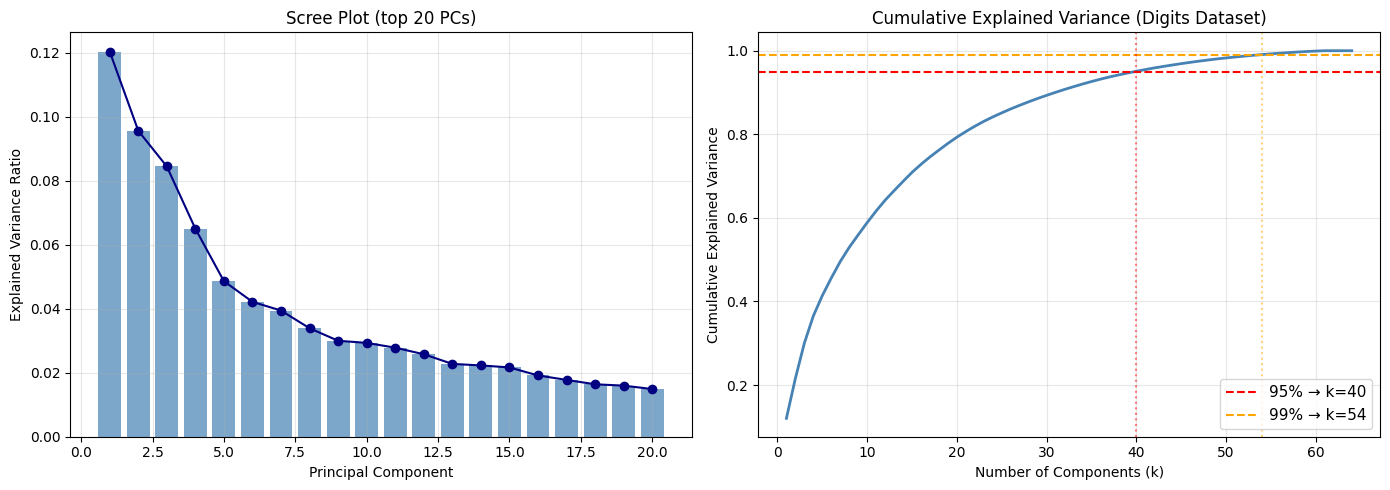

Original dimensions: 64
Components for 95% variance: 40 (62% of original)
Components for 99% variance: 54 (84% of original)


In [4]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

digits = load_digits()
X_digits = digits.data  # 1797 samples, 64 features (8x8 pixels)

# Standardize
X_c = X_digits - X_digits.mean(axis=0)
X_c /= (X_c.std(axis=0) + 1e-8)

# Full covariance decomposition
cov_d = X_c.T @ X_c / (len(X_c) - 1)
eigvals_d, eigvecs_d = np.linalg.eigh(cov_d)
eigvals_d = eigvals_d[::-1]
eigvecs_d = eigvecs_d[:, ::-1]

total_var = eigvals_d.sum()
evr = eigvals_d / total_var
cum_evr = np.cumsum(evr)

# Find k for 95% explained variance
k_95 = np.searchsorted(cum_evr, 0.95) + 1
k_99 = np.searchsorted(cum_evr, 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
ax1 = axes[0]
ax1.bar(range(1, 21), evr[:20], color='steelblue', alpha=0.7)
ax1.plot(range(1, 21), evr[:20], 'o-', color='navy')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot (top 20 PCs)')
ax1.grid(True, alpha=0.3)

# Cumulative explained variance
ax2 = axes[1]
ax2.plot(range(1, len(cum_evr)+1), cum_evr, color='steelblue', lw=2)
ax2.axhline(0.95, color='red', linestyle='--', label=f'95% → k={k_95}')
ax2.axhline(0.99, color='orange', linestyle='--', label=f'99% → k={k_99}')
ax2.axvline(k_95, color='red', linestyle=':', alpha=0.5)
ax2.axvline(k_99, color='orange', linestyle=':', alpha=0.5)
ax2.set_xlabel('Number of Components (k)')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance (Digits Dataset)')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_explained_variance.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Original dimensions: {X_digits.shape[1]}")
print(f"Components for 95% variance: {k_95} ({k_95/X_digits.shape[1]*100:.0f}% of original)")
print(f"Components for 99% variance: {k_99} ({k_99/X_digits.shape[1]*100:.0f}% of original)")

---
## 8. Reconstruction and Information Loss

### The Reconstruction

After projecting to $k$ dimensions, we can **reconstruct** an approximation of the original data:

$$\hat{X} = Z W^T + \bar{X}$$

where $Z = (X - \bar{X}) W$ is the projected data.

### Reconstruction Error

The **mean squared reconstruction error** is:

$$\text{MSE} = \frac{1}{n} \|X - \hat{X}\|_F^2 = \sum_{i=k+1}^{d} \lambda_i$$

The error equals the sum of **discarded eigenvalues** — exactly the variance we threw away.

### Why This Matters for Images

PCA compression of images is a classic demonstration: with $k$ components, we store $k$ coefficients per image instead of $d$ pixels. The reconstruction is blurry but recognizable, and improves as $k$ increases.

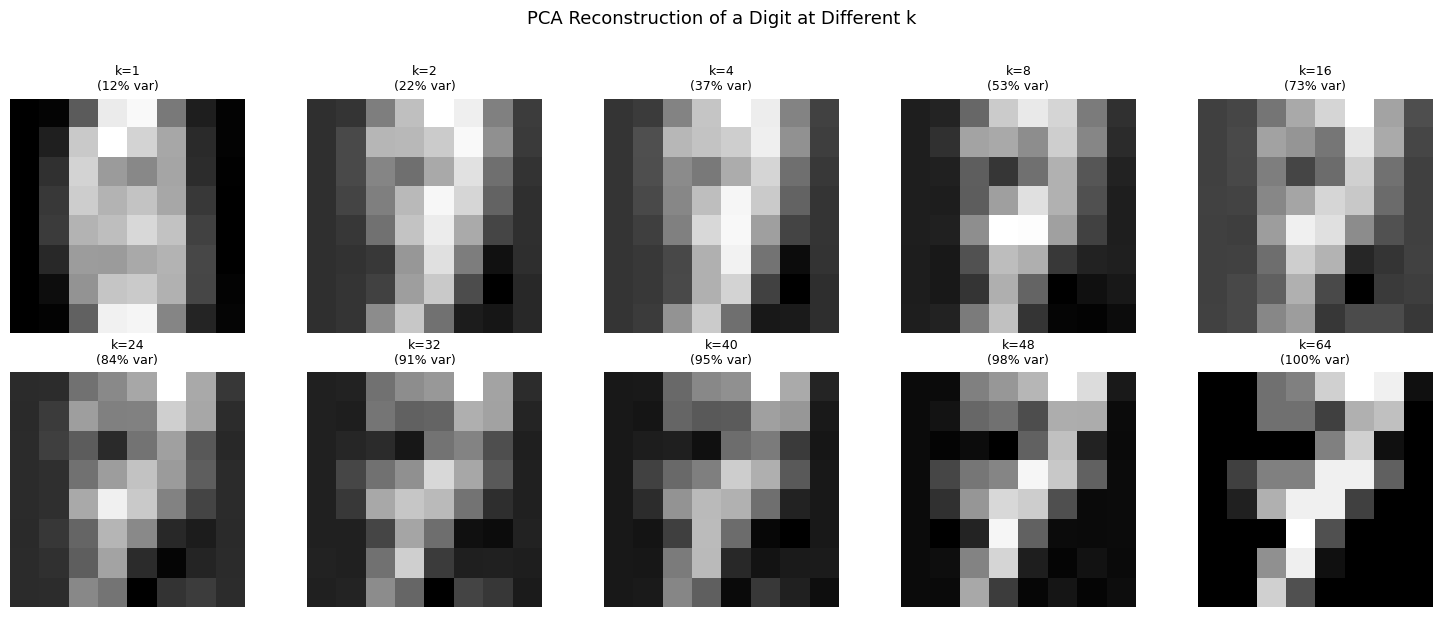

In [5]:
# PCA reconstruction of digit images
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

# Pick one sample digit
sample = X_scaled[7:8]  # shape (1, 64)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
k_values = [1, 2, 4, 8, 16, 24, 32, 40, 48, 64]

for ax, k in zip(axes.flat, k_values):
    # Project and reconstruct using top k eigenvectors
    W_k = eigvecs_d[:, :k]
    z_k = sample @ W_k
    recon = z_k @ W_k.T
    recon_original = scaler.inverse_transform(recon)
    ax.imshow(recon_original.reshape(8, 8), cmap='gray')
    var_explained = cum_evr[k-1] * 100
    ax.set_title(f'k={k}\n({var_explained:.0f}% var)', fontsize=9)
    ax.axis('off')

plt.suptitle('PCA Reconstruction of a Digit at Different k', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('pca_reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. PCA vs Feature Selection

| Aspect | PCA | Feature Selection |
|---|---|---|
| Method | Creates **new features** (linear combinations) | Selects **original features** |
| Interpretability | Components are hard to interpret directly | Original feature names retained |
| Information | Maximally preserves variance | May discard useful variance |
| Correlation | Removes correlations between features | Correlated features may remain |
| Use case | Image/signal processing, visualization | When feature interpretability matters |

PCA is **not** feature selection — it creates entirely new axes. You cannot say "feature 3 was removed" after PCA.

### When to Use PCA
- Visualization (reduce to 2D or 3D)
- Preprocessing before a model that struggles with high-dimensional/correlated data
- Noise reduction (low-variance components often capture noise)
- Compression (store fewer numbers per sample)
- Speeding up slow algorithms (SVM, neural nets)

### When NOT to Use PCA
- When feature interpretability is required
- When data has non-linear structure (consider t-SNE, UMAP, or Kernel PCA)
- When you have very few samples (can overfit the covariance estimate)
- When you need reproducible feature names for a business stakeholder

---
## 10. Limitations of PCA

### 1. Linearity
PCA only captures **linear** structure. If the true low-dimensional manifold is curved (like a Swiss roll), PCA fails. Use Kernel PCA, t-SNE, or UMAP.

### 2. Variance ≠ Information
PCA assumes high variance = important. But sometimes the **low-variance** direction is the informative one. Example: in a dataset of healthy vs diseased patients, the disease signal might lie in a low-variance direction.

### 3. Scale Sensitivity
PCA is not scale-invariant. Features measured in different units (km vs grams) must be standardized first, otherwise large-scale features dominate.

### 4. Outlier Sensitivity
Outliers have a large effect on the covariance matrix and thus on the principal components. Consider **Robust PCA** for outlier-heavy data.

### 5. Interpretability
Each principal component is a linear combination of ALL original features, making it hard to interpret. **Sparse PCA** constrains components to use few original features.

### 6. No Class Information
PCA is **unsupervised** — it doesn't use class labels. If you want to separate classes, use **LDA (Linear Discriminant Analysis)** which finds directions that maximize class separation.

---
## 11. Implementation from Scratch

In [6]:
import numpy as np

class PCAFromScratch:
    """
    PCA via covariance matrix eigen decomposition.
    """
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None      # eigenvectors (principal axes)
        self.explained_variance_ = None  # eigenvalues
        self.explained_variance_ratio_ = None
        self.mean_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        cov = X_centered.T @ X_centered / (len(X) - 1)

        eigvals, eigvecs = np.linalg.eigh(cov)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        self.components_ = eigvecs[:, :self.n_components].T  # shape (k, d)
        self.explained_variance_ = eigvals[:self.n_components]
        self.explained_variance_ratio_ = eigvals[:self.n_components] / eigvals.sum()
        return self

    def transform(self, X):
        X_centered = X - self.mean_
        return X_centered @ self.components_.T  # shape (n, k)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, Z):
        return Z @ self.components_ + self.mean_


# Test on iris dataset
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

# Our implementation
pca_scratch = PCAFromScratch(n_components=2)
Z_scratch = pca_scratch.fit_transform(X_iris)

# sklearn implementation
pca_sk = SklearnPCA(n_components=2)
Z_sk = pca_sk.fit_transform(X_iris)

print("Explained variance ratio (scratch):", np.round(pca_scratch.explained_variance_ratio_, 4))
print("Explained variance ratio (sklearn):", np.round(pca_sk.explained_variance_ratio_, 4))

# Results match up to sign flip
print("\nProjected data matches sklearn (up to sign):",
      np.allclose(np.abs(Z_scratch), np.abs(Z_sk), atol=1e-6))

Explained variance ratio (scratch): [0.7296 0.2285]
Explained variance ratio (sklearn): [0.7296 0.2285]

Projected data matches sklearn (up to sign): True


---
### 11.1 Visual Comparison — Scratch vs. sklearn on a Toy Dataset

The check above confirms the scratch implementation matches sklearn *numerically* (explained variance ratio, projected coordinates up to sign). To make the match visually obvious, project a small toy 2D-correlated dataset with both implementations and plot the resulting 1D projections side by side.

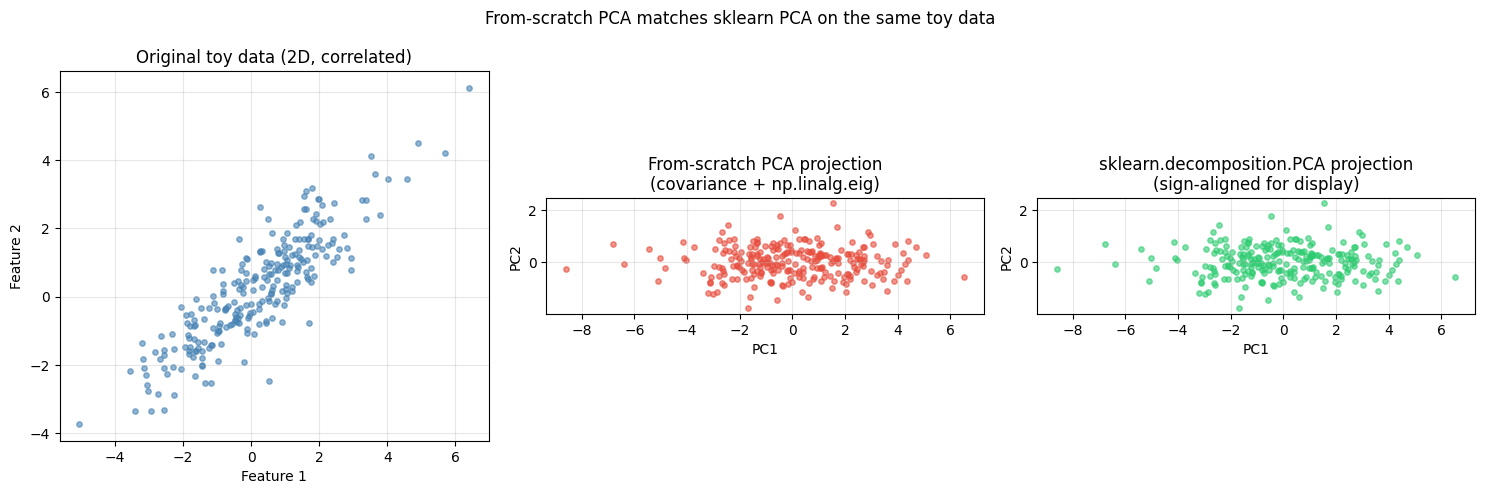

Max abs difference after sign-alignment: 1.942890293094024e-15


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as SklearnPCA

# Toy correlated 2D dataset (same style as the geometric-intuition demo in Section 3)
rng = np.random.default_rng(0)
mean_toy = [0, 0]
cov_toy = [[3, 2.4], [2.4, 2.5]]
X_toy2d = rng.multivariate_normal(mean_toy, cov_toy, 250)

# Project onto top-2 components with both implementations
Z_scratch_2d = PCAFromScratch(n_components=2).fit_transform(X_toy2d)
Z_sklearn_2d = SklearnPCA(n_components=2).fit_transform(X_toy2d)

# sklearn's sign convention can flip an axis relative to ours — align for display
for j in range(2):
    if np.dot(Z_scratch_2d[:, j], Z_sklearn_2d[:, j]) < 0:
        Z_sklearn_2d[:, j] *= -1

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(X_toy2d[:, 0], X_toy2d[:, 1], s=15, alpha=0.6, color='steelblue')
axes[0].set_title('Original toy data (2D, correlated)')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].set_aspect('equal'); axes[0].grid(True, alpha=0.3)

axes[1].scatter(Z_scratch_2d[:, 0], Z_scratch_2d[:, 1], s=15, alpha=0.6, color='#e74c3c')
axes[1].set_title('From-scratch PCA projection\n(covariance + np.linalg.eig)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_aspect('equal'); axes[1].grid(True, alpha=0.3)

axes[2].scatter(Z_sklearn_2d[:, 0], Z_sklearn_2d[:, 1], s=15, alpha=0.6, color='#2ecc71')
axes[2].set_title('sklearn.decomposition.PCA projection\n(sign-aligned for display)')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].set_aspect('equal'); axes[2].grid(True, alpha=0.3)

plt.suptitle('From-scratch PCA matches sklearn PCA on the same toy data', fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig('pca_scratch_vs_sklearn.png', dpi=120, bbox_inches='tight')
plt.show()

print("Max abs difference after sign-alignment:",
      np.max(np.abs(Z_scratch_2d - Z_sklearn_2d)))

---
## 12. sklearn PCA on Real Data

Original shape: (569, 30)
Reduced shape:  (569, 10)
Cumulative variance explained: 95.2%

Variance per component:
  PC1: 44.3%
  PC2: 19.0%
  PC3: 9.4%
  PC4: 6.6%
  PC5: 5.5%
  PC6: 4.0%
  PC7: 2.3%
  PC8: 1.6%
  PC9: 1.4%
  PC10: 1.2%


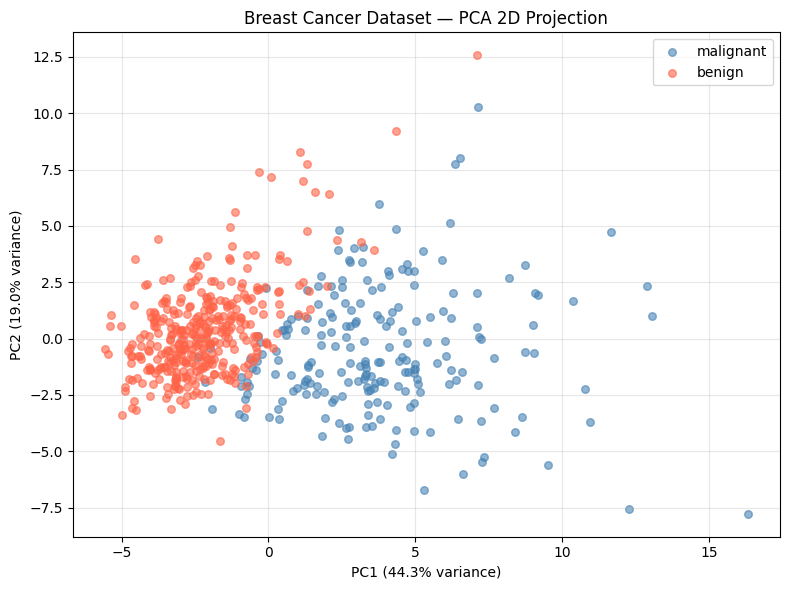

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import numpy as np

cancer = load_breast_cancer()
X_cancer = StandardScaler().fit_transform(cancer.data)

# Fit PCA keeping enough for 95% variance
pca = PCA(n_components=0.95)  # sklearn accepts a float: keep until % explained
X_pca = pca.fit_transform(X_cancer)

print(f"Original shape: {X_cancer.shape}")
print(f"Reduced shape:  {X_pca.shape}")
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"\nVariance per component:")
for i, r in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {r*100:.1f}%")

# Plot first 2 PCs colored by label
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_cancer)

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'tomato']
labels = cancer.target_names
for cls, color, label in zip([0, 1], colors, labels):
    mask = cancer.target == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=label, alpha=0.6, s=30)
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Breast Cancer Dataset — PCA 2D Projection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_breast_cancer.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 13. PCA for Visualization

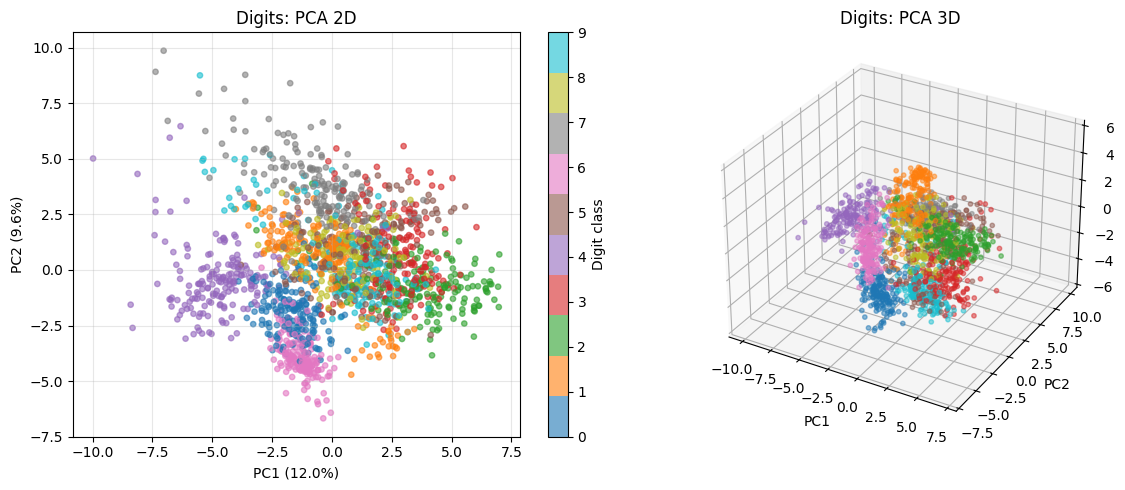

Variance explained by top 3 PCs: 30.0%


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

digits = load_digits()
X_d = StandardScaler().fit_transform(digits.data)

pca3 = PCA(n_components=3)
X_3d = pca3.fit_transform(X_d)

fig = plt.figure(figsize=(12, 5))

# 2D
ax1 = fig.add_subplot(121)
scatter = ax1.scatter(X_3d[:, 0], X_3d[:, 1], c=digits.target,
                      cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, ax=ax1, label='Digit class')
ax1.set_xlabel(f'PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('Digits: PCA 2D')
ax1.grid(True, alpha=0.3)

# 3D
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
                       c=digits.target, cmap='tab10', alpha=0.5, s=10)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.set_title('Digits: PCA 3D')

plt.tight_layout()
plt.savefig('pca_digits_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

print("Variance explained by top 3 PCs:",
      f"{pca3.explained_variance_ratio_.sum()*100:.1f}%")

---
## 14. Kernel PCA

### Why Kernel PCA?

Standard PCA can only find **linear** structure. If the data lives on a non-linear manifold (e.g., a circle, spiral, or Swiss roll), linear PCA fails to separate it meaningfully.

### The Kernel Trick

Instead of working in the original feature space $\mathbb{R}^d$, map data to a high-dimensional feature space $\phi: \mathbb{R}^d \to \mathcal{H}$ and apply PCA there.

We never compute $\phi(x)$ explicitly. Instead, we use a **kernel function**:

$$k(x_i, x_j) = \langle \phi(x_i), \phi(x_j) \rangle$$

Common kernels:
- **RBF (Gaussian)**: $k(x,y) = \exp\left(-\frac{\|x-y\|^2}{2\sigma^2}\right)$ — most popular
- **Polynomial**: $k(x,y) = (x^T y + c)^p$
- **Sigmoid**: $k(x,y) = \tanh(\alpha x^T y + c)$

Kernel PCA operates on the **kernel matrix** $K$ ($n \times n$) rather than the covariance matrix ($d \times d$), making it suitable when $d >> n$.

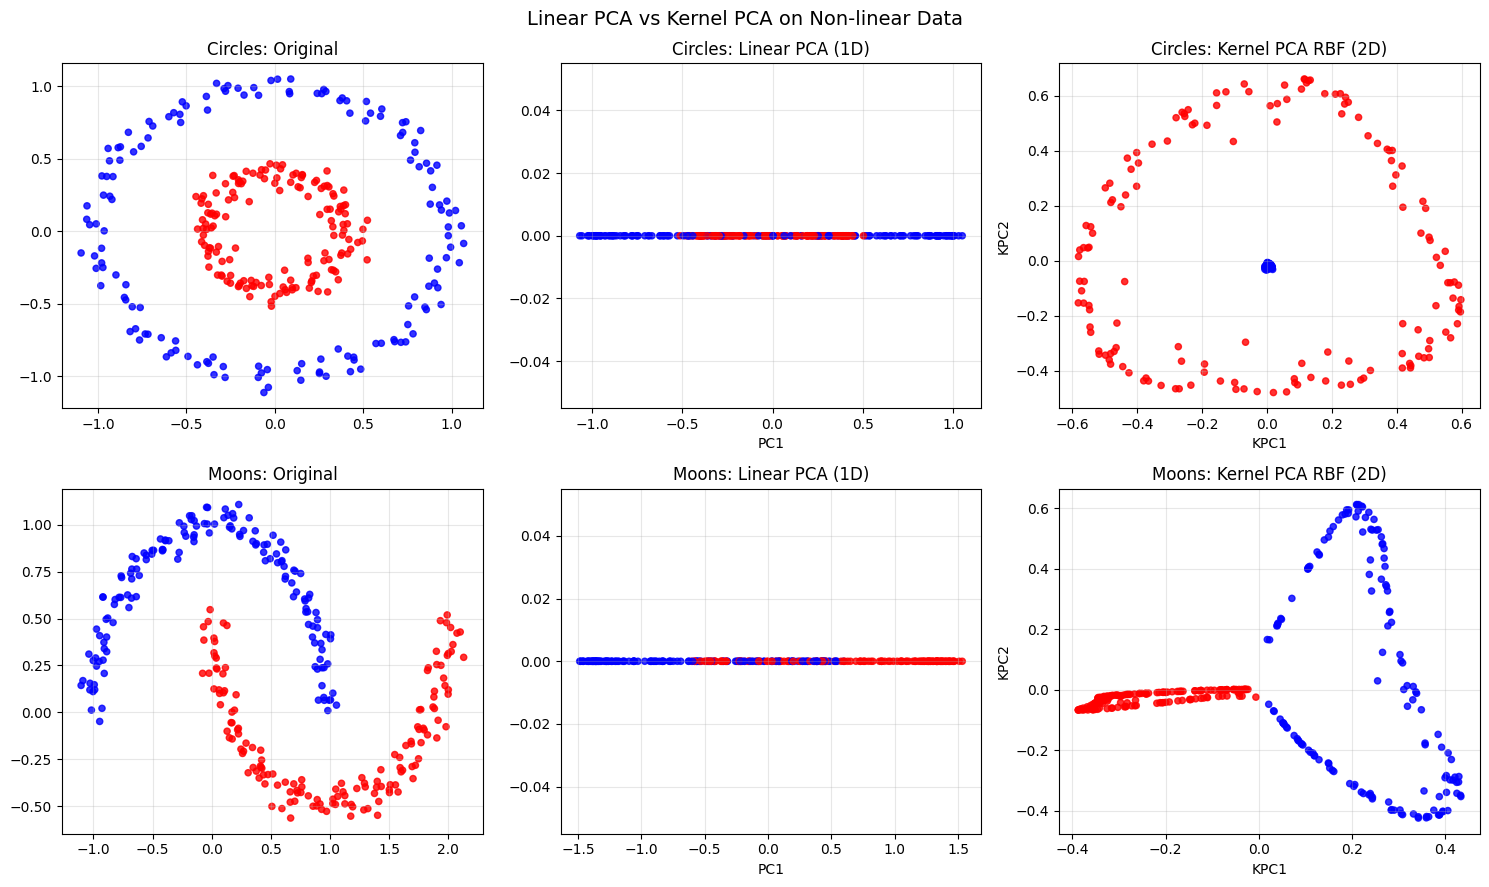

In [10]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles, make_moons
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

datasets = [
    ('Circles', make_circles(n_samples=300, noise=0.05, factor=0.4, random_state=42)),
    ('Moons',   make_moons(n_samples=300, noise=0.05, random_state=42)),
]

for row, (name, (X_nl, y_nl)) in enumerate(datasets):
    # Original data
    axes[row, 0].scatter(X_nl[:, 0], X_nl[:, 1], c=y_nl, cmap='bwr', s=20, alpha=0.8)
    axes[row, 0].set_title(f'{name}: Original')
    axes[row, 0].grid(True, alpha=0.3)

    # Linear PCA
    Z_linear = PCA(n_components=1).fit_transform(X_nl)
    axes[row, 1].scatter(Z_linear, np.zeros_like(Z_linear), c=y_nl, cmap='bwr', s=20, alpha=0.8)
    axes[row, 1].set_title(f'{name}: Linear PCA (1D)')
    axes[row, 1].set_xlabel('PC1')
    axes[row, 1].grid(True, alpha=0.3)

    # Kernel PCA (RBF)
    Z_kernel = KernelPCA(n_components=2, kernel='rbf', gamma=15).fit_transform(X_nl)
    axes[row, 2].scatter(Z_kernel[:, 0], Z_kernel[:, 1], c=y_nl, cmap='bwr', s=20, alpha=0.8)
    axes[row, 2].set_title(f'{name}: Kernel PCA RBF (2D)')
    axes[row, 2].set_xlabel('KPC1')
    axes[row, 2].set_ylabel('KPC2')
    axes[row, 2].grid(True, alpha=0.3)

plt.suptitle('Linear PCA vs Kernel PCA on Non-linear Data', fontsize=14)
plt.tight_layout()
plt.savefig('kernel_pca.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 15. Summary

### Core Idea
PCA finds a new coordinate system aligned with the directions of maximum variance in the data. It does this by computing the **eigenvectors of the covariance matrix**.

### The Math in One Slide

| Step | Math |
|---|---|
| Center data | $\tilde{X} = X - \bar{X}$ |
| Covariance | $\Sigma = \frac{1}{n-1}\tilde{X}^T\tilde{X}$ |
| Decompose | $\Sigma \mathbf{v}_i = \lambda_i \mathbf{v}_i$ |
| Project | $Z = \tilde{X} W$ where $W = [\mathbf{v}_1,\dots,\mathbf{v}_k]$ |
| Reconstruct | $\hat{X} = ZW^T + \bar{X}$ |

### Key Facts to Remember

1. **Eigenvalue = variance** explained by that component
2. **Eigenvectors are orthogonal** — components are uncorrelated after PCA
3. **Always center** (and usually standardize) before PCA
4. **SVD** is numerically preferred over direct eigen decomposition
5. **Explained variance ratio** helps you choose $k$
6. PCA is **linear** — use Kernel PCA for non-linear data
7. Reconstruction error = sum of **discarded eigenvalues**

### PCA in the ML Pipeline

```
Raw Data
    ↓
StandardScaler  (fit on train only!)
    ↓
PCA(n_components=k)  (fit on train only!)
    ↓
Downstream Model (SVM, Logistic Regression, etc.)
```

> **Critical**: Always fit PCA on the **training set only**, then use `transform` on the test set. Never fit on the full dataset — that leaks test information.

In [11]:
# Correct PCA pipeline with sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_breast_cancer
import numpy as np

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42, stratify=cancer.target
)

# Pipeline: scaler → PCA → classifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10)),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)

# Without PCA
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])
baseline.fit(X_train, y_train)
baseline_acc = baseline.score(X_test, y_test)

print(f"Features used with PCA:    10 (of 30)")
print(f"Test accuracy with PCA:    {test_acc:.4f}")
print(f"Test accuracy without PCA: {baseline_acc:.4f}")
print(f"\nVariance explained by top 10 PCs: "
      f"{pipeline.named_steps['pca'].explained_variance_ratio_.sum()*100:.1f}%")

Features used with PCA:    10 (of 30)
Test accuracy with PCA:    0.9737
Test accuracy without PCA: 0.9825

Variance explained by top 10 PCs: 95.3%
